**Загрузка датасета MoviesOnStreamingPlatforms и очистка данных**

In [2]:
import pandas as pd

# Загрузка данных в DataFrame
df = pd.read_csv("MoviesOnStreamingPlatforms.csv")

# Вывод общей информации о данных
print(df.info())
# Вывод первых 5 строк для обзора
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       9515 non-null   int64 
 1   ID               9515 non-null   int64 
 2   Title            9515 non-null   object
 3   Year             9515 non-null   int64 
 4   Age              5338 non-null   object
 5   Rotten Tomatoes  9508 non-null   object
 6   Netflix          9515 non-null   int64 
 7   Hulu             9515 non-null   int64 
 8   Prime Video      9515 non-null   int64 
 9   Disney+          9515 non-null   int64 
 10  Type             9515 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 817.8+ KB
None


,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


In [3]:
df

,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9510,9510,9511,Most Wanted Sharks,2020,NaN,14/100,0,0,0,1,0
9511,9511,9512,Doc McStuffins: The Doc Is In,2020,NaN,13/100,0,0,0,1,0
9512,9512,9513,Ultimate Viking Sword,2019,NaN,13/100,0,0,0,1,0
9513,9513,9514,Hunt for the Abominable Snowman,2011,NaN,10/100,0,0,0,1,0


In [4]:
# Удаляем ненужные столбцы: 'Unnamed: 0', 'ID', 'Type'
df.drop(columns=['Unnamed: 0', 'ID', 'Type'], inplace=True)

# Обработка столбца Age: заполняем пропуски значением 'Unknown'
df['Age'].fillna('Unknown', inplace=True)

# Обработка столбца Rotten Tomatoes: удаляем суффикс "%/100" и преобразуем к числовому типу
# Сначала заменим строковое представление на число, игнорируя пропуски
df['Rotten Tomatoes'] = df['Rotten Tomatoes'].str.replace('/100', '')
df['Rotten Tomatoes'] = pd.to_numeric(df['Rotten Tomatoes'], errors='coerce')
# Заполним оставшиеся пропуски (NaN) медианным значением рейтинга
median_rating = df['Rotten Tomatoes'].median()
df['Rotten Tomatoes'].fillna(median_rating, inplace=True)

# Проверяем результат очистки
df.info()
df.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            9515 non-null   object 
 1   Year             9515 non-null   int64  
 2   Age              9515 non-null   object 
 3   Rotten Tomatoes  9515 non-null   float64
 4   Netflix          9515 non-null   int64  
 5   Hulu             9515 non-null   int64  
 6   Prime Video      9515 non-null   int64  
 7   Disney+          9515 non-null   int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 594.8+ KB


,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+
0,The Irishman,2019,18+,98.0,1,0,0,0
1,Dangal,2016,7+,97.0,1,0,0,0
2,David Attenborough: A Life on Our Planet,2020,7+,95.0,1,0,0,0
3,Lagaan: Once Upon a Time in India,2001,7+,94.0,1,0,0,0
4,Roma,2018,18+,94.0,1,0,0,0


**Разведочный анализ данных (EDA)**

 Рассмотрим

- Количество фильмов на каждой платформе (Netflix, Hulu, Prime Video, Disney+).

- Распределение фильмов по возрастным рейтингам.

- Распределение по годам выпуска.

- Распределение оценок качества (рейтинг Rotten Tomatoes).

- Пересечения между платформами – сколько фильмов доступны на нескольких платформах одновременно.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Количество фильмов на каждой платформе
platform_counts = {
    'Netflix': df['Netflix'].sum(),
    'Hulu': df['Hulu'].sum(),
    'Prime Video': df['Prime Video'].sum(),
    'Disney+': df['Disney+'].sum()
}
print("Количество фильмов на платформах:", platform_counts)

plt.figure(figsize=(6,4))
plt.bar(platform_counts.keys(), platform_counts.values(), color=['#e41a1c','#377eb8','#4daf4a','#ffd92f'])
plt.title("Число фильмов на каждой платформе")   
plt.ylabel("Количество фильмов")
plt.show()


- Amazon Prime Video предлагает больше всего фильмов – около 4100 (самый высокий столбец).

- Netflix имеет примерно 3700 фильмов.

- Hulu и Disney+ значительно уступают по количеству: у Hulu около 1000 фильмов, у Disney+ примерно 700–800.

Разница объясняется тем, что Prime Video и Netflix имеют более обширные библиотеки, тогда как Disney+ специализируется на собственном контенте (Disney, Marvel и т.д.) и Hulu также имеет более ограниченный каталог.

Распределение Age-рейтингов:
 Age
Unknown    4177
18+        2276
7+         1090
13+         998
all         698
16+         276
Name: count, dtype: int64


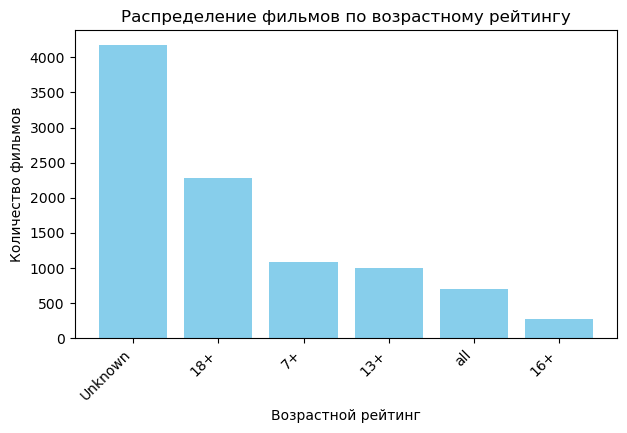

In [14]:
# Распределение фильмов по возрастным рейтингам
age_counts = df['Age'].value_counts()
print("Распределение Age-рейтингов:\n", age_counts)

plt.figure(figsize=(7,4))
plt.bar(age_counts.index, age_counts.values, color='skyblue')
plt.title("Распределение фильмов по возрастному рейтингу")
plt.xlabel("Возрастной рейтинг")
plt.ylabel("Количество фильмов")
plt.xticks(rotation=45, ha='right')
plt.show()

- Большая часть фильмов имеет рейтинг “18+” (взрослая аудитория) – этот столбец самый высокий. Также много фильмов с рейтингами “13+” и “7+”.

- Категория “all” (для всех возрастов) представлена заметно меньшим числом фильмов.

- Присутствует значительная категория “Unknown” – это фильмы, для которых возрастной рейтинг не указан в данных (мы обозначили их как "Unknown"). Таких фильмов довольно много (порядка 44% от всех, судя по высоте столбца). Их наличие говорит о неполноте исходных данных: для почти половины фильмов возрастной ценз неизвестен, возможно, потому что эти данные отсутствовали в исходном источнике.

Если исключить неизвестные, то преобладают фильмы для взрослой аудитории (18+), что ожидаемо, учитывая, что каталоги Netflix и особенно Prime Video содержат много контента для зрелой аудитории.

Количество фильмов по десятилетиям:
 Decade
1910       5
1920      15
1930     161
1940     174
1950     174
1960     112
1970     219
1980     307
1990     506
2000    1294
2010    5359
2020    1189
Name: count, dtype: int64


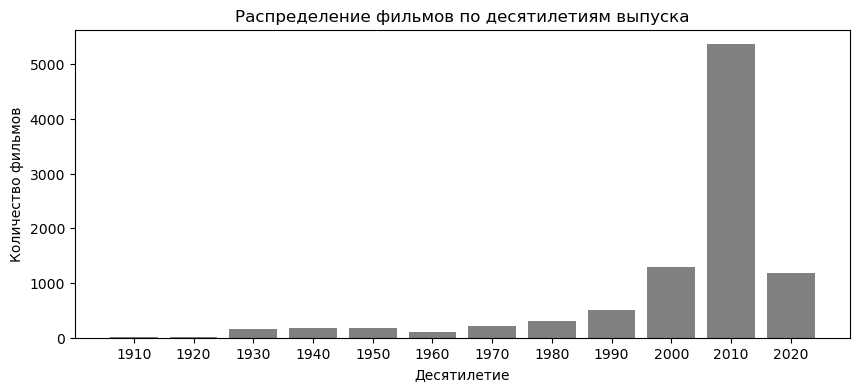

In [15]:
# Распределение по годам выпуска
# Добавим столбец десятилетия для наглядности
df['Decade'] = (df['Year'] // 10) * 10
decade_counts = df['Decade'].value_counts().sort_index()
print("Количество фильмов по десятилетиям:\n", decade_counts)

plt.figure(figsize=(10,4))
plt.bar(decade_counts.index.astype(str), decade_counts.values, color='gray')
plt.title("Распределение фильмов по десятилетиям выпуска")
plt.xlabel("Десятилетие")
plt.ylabel("Количество фильмов")
plt.show()

Распределение фильмов по годам выпуска показывает следующие тенденции:

- Основной рост количества фильмов приходится на последние десятилетия. На графике столбцы значительно увеличиваются начиная с 1990-х и особенно в 2000-х и 2010-х годах.

- Максимум приходится на 2010-е годы – в этот период вышло наибольшее число фильмов из представленных на платформах. Также много фильмов 2000-х.

- Более старые фильмы (до 1980-х) представлены, но их существенно меньше. Например, фильмы 1960-х, 1950-х и ранее – единицы или десятки (совсем низкие столбцы). Это логично: стриминговые сервисы больше ориентированы на современный контент, а также многие старые фильмы недоступны или нецифрованы.

- В целом, платформа Amazon Prime имеет самую большую библиотеку, включающую много старых фильмов (об этом свидетельствует наличие некоторого количества фильмов даже из 1940-х и 1930-х годов на графике). Netflix, Hulu и Disney+ фокусируются больше на современном контенте. Поэтому видим небольшой "хвост" старых фильмов, но основной контент – это последние ~30 лет.

Статистика рейтингов Rotten Tomatoes:
 Мин: 10.0 | Макс: 98.0 | Средний: 53.54387808723069 | Медиана: 52.0


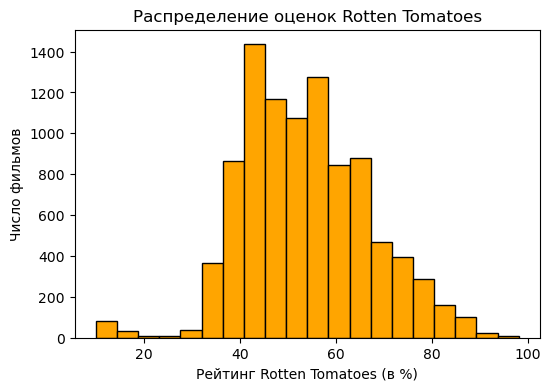

In [16]:
# Распределение рейтингов Rotten Tomatoes
ratings = df['Rotten Tomatoes']
print("Статистика рейтингов Rotten Tomatoes:")
print(" Мин:", ratings.min(), "| Макс:", ratings.max(), "| Средний:", ratings.mean(), "| Медиана:", ratings.median())

plt.figure(figsize=(6,4))
plt.hist(ratings, bins=20, color='orange', edgecolor='black')
plt.title("Распределение оценок Rotten Tomatoes")
plt.xlabel("Рейтинг Rotten Tomatoes (в %)")
plt.ylabel("Число фильмов")
plt.show()

Распределение по числу платформ:
 PlatformCount
1    9262
2     245
3       7
4       1
Name: count, dtype: int64


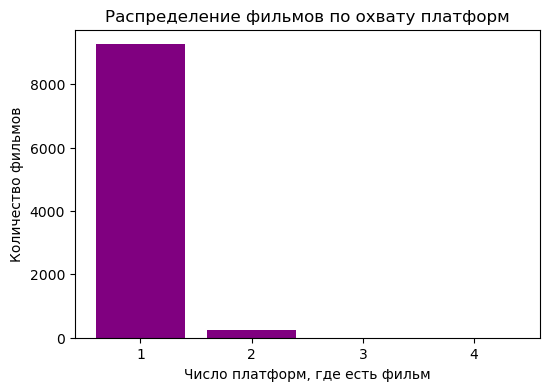

In [17]:
# Пересечения между платформами: число платформ, на которых доступен фильм
# Рассчитаем для каждого фильма, на скольких платформах он представлен
df['PlatformCount'] = df[['Netflix','Hulu','Prime Video','Disney+']].sum(axis=1)
platform_count_dist = df['PlatformCount'].value_counts().sort_index()
print("Распределение по числу платформ:\n", platform_count_dist)

plt.figure(figsize=(6,4))
plt.bar(platform_count_dist.index.astype(str), platform_count_dist.values, color='purple')
plt.title("Распределение фильмов по охвату платформ")
plt.xlabel("Число платформ, где есть фильм")
plt.ylabel("Количество фильмов")
plt.show()


# ABC-анализ и XYZ-анализ по охвату платформ

ABC-анализ: разделим фильмы на три категории A, B, C на основе охвата (числа платформ):

A – фильмы с широким охватом (представлены на многих платформах).

B – фильмы со средним охватом.

C – фильмы с узким охватом (только на одной платформе).

XYZ-анализ: разделим фильмы на категории X, Y, Z по стабильности охвата:

X – "стабильный" охват: фильм присутствует на всех основных платформах (максимально широкое распространение, значит его наличие наиболее устойчиво – если с одной платформы уберут, он доступен на других).

Y – умеренная стабильность: фильм доступен на нескольких (но не всех) платформах.

Z – низкая стабильность: фильм есть только на одной платформе (если платформа уберет фильм, больше его нигде нет).

In [18]:
# Расчет охвата (число платформ) уже выполнен в столбце PlatformCount
coverage = df['PlatformCount']

# ABC категории:
A_films = coverage[coverage >= 3].count()   # фильмы на 3 или 4 платформах
B_films = coverage[coverage == 2].count()   # фильмы на 2 платформах
C_films = coverage[coverage == 1].count()   # фильмы на 1 платформе

print(f"ABC-разбиение по охвату платформ:\n A: {A_films} 
фильмов (3-4 платформы)\n B: {B_films} фильмов (2 платформы)\n C: {C_films} фильмов (1 платформа)")

# XYZ категории:
X_films = coverage[coverage == 4].count()                        # фильмы на 4 платформах
Y_films = coverage[(coverage == 2) | (coverage == 3)].count()    # фильмы на 2 или 3 платформах
Z_films = coverage[coverage == 1].count()                        # фильмы на 1 платформе

print(f"\nXYZ-разбиение по стабильности охвата:\n X: {X_films} фильмов (на 4 платформах)\n Y
: {Y_films} фильмов (на 2-3 платформах)\n Z: {Z_films} фильмов (на 1 платформе)")


ABC-разбиение по охвату платформ:
 A: 8 фильмов (3-4 платформы)
 B: 245 фильмов (2 платформы)
 C: 9262 фильмов (1 платформа)

XYZ-разбиение по стабильности охвата:
 X: 1 фильмов (на 4 платформах)
 Y: 252 фильмов (на 2-3 платформах)
 Z: 9262 фильмов (на 1 платформе)


In [19]:
# Расчет охвата (число платформ) уже выполнен в столбце PlatformCount
coverage = df['PlatformCount']

# ABC категории:
A_films = coverage[coverage >= 3].count()   # фильмы на 3 или 4 платформах
B_films = coverage[coverage == 2].count()   # фильмы на 2 платформах
C_films = coverage[coverage == 1].count()   # фильмы на 1 платформе

print(f"ABC-разбиение по охвату платформ:\n A: {A_films} фильмов (3-4 платформы)\n B: {B_films} фильмов (2 платформы)\n C: {C_films} фильмов (1 платформа)")

# XYZ категории:
X_films = coverage[coverage == 4].count()                        # фильмы на 4 платформах
Y_films = coverage[(coverage == 2) | (coverage == 3)].count()    # фильмы на 2 или 3 платформах
Z_films = coverage[coverage == 1].count()                        # фильмы на 1 платформе

print(f"\nXYZ-разбиение по стабильности охвата:\n X: {X_films} фильмов (на 4 платформах)\n Y: {Y_films} фильмов (на 2-3 платформах)\n Z: {Z_films} фильмов (на 1 платформе)")


ABC-разбиение по охвату платформ:
 A: 8 фильмов (3-4 платформы)
 B: 245 фильмов (2 платформы)
 C: 9262 фильмов (1 платформа)

XYZ-разбиение по стабильности охвата:
 X: 1 фильмов (на 4 платформах)
 Y: 252 фильмов (на 2-3 платформах)
 Z: 9262 фильмов (на 1 платформе)


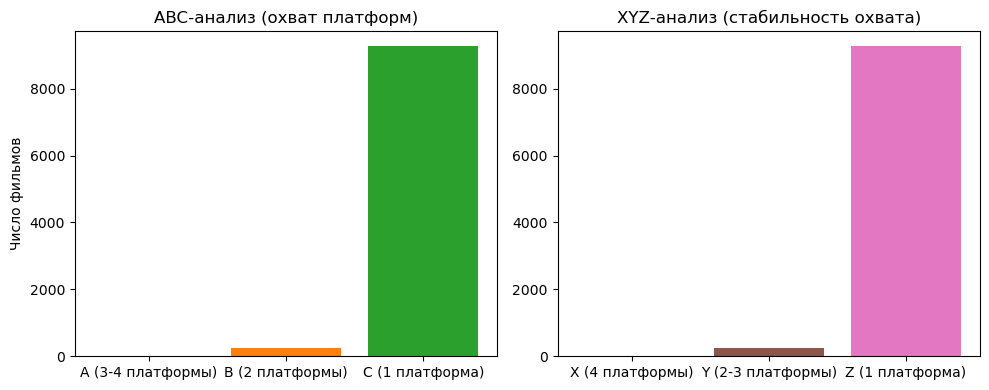

In [20]:
# Визуализация ABC vs XYZ распределения
labels_abc = ['A (3-4 платформы)', 'B (2 платформы)', 'C (1 платформа)']
counts_abc = [A_films, B_films, C_films]

labels_xyz = ['X (4 платформы)', 'Y (2-3 платформы)', 'Z (1 платформа)']
counts_xyz = [X_films, Y_films, Z_films]

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].bar(labels_abc, counts_abc, color=['#1f77b4','#ff7f0e','#2ca02c'])
axes[0].set_title("ABC-анализ (охват платформ)")
axes[0].set_ylabel("Число фильмов")

axes[1].bar(labels_xyz, counts_xyz, color=['#9467bd','#8c564b','#e377c2'])
axes[1].set_title("XYZ-анализ (стабильность охвата)")

plt.tight_layout()
plt.show()


# RFM-анализ фильмов

In [21]:
# Создаем копии признаков для удобства
movies = df.copy()

# 1. Recency: разделим фильмы на 3 группы по году выпуска (новые, средние, старые)
# Используем квантильное разбиение на три равных группы
movies['R_segment'] = pd.qcut(movies['Year'], q=3, labels=['Old','Medium','New'])

# 2. Frequency: 1 платформа = Low, 2 = Medium, 3-4 = High
movies['F_segment'] = movies['PlatformCount'].apply(lambda x: 'High' if x >= 3 else ('Medium' if x == 2 else 'Low'))

# 3. Monetary: рейтинг Rotten Tomatoes разбиваем на 3 группы (низкий, средний, высокий)
movies['M_segment'] = pd.qcut(movies['Rotten Tomatoes'], q=3, labels=['Low','Medium','High'])

# Посмотрим распределение по сегментам
print("Recency распределение:\n", movies['R_segment'].value_counts())
print("Frequency распределение:\n", movies['F_segment'].value_counts())
print("Monetary распределение:\n", movies['M_segment'].value_counts())


Recency распределение:
 R_segment
Medium    3191
Old       3176
New       3148
Name: count, dtype: int64
Frequency распределение:
 F_segment
Low       9262
Medium     245
High         8
Name: count, dtype: int64
Monetary распределение:
 M_segment
Low       3423
High      3163
Medium    2929
Name: count, dtype: int64


In [22]:
# Выделим определенные сегменты RFM
# 1. Лучшие (новые, широкий охват, высокорейтинговые)
best_segment = movies[(movies['R_segment']=='New') & (movies['F_segment']=='High') & (movies['M_segment']=='High')]
# 2. Худшие (старые, узкий охват, низкорейтинговые)
worst_segment = movies[(movies['R_segment']=='Old') & (movies['F_segment']=='Low') & (movies['M_segment']=='Low')]

print("Фильмов в сегменте BEST (New, High, High):", best_segment.shape[0])
print("Фильмов в сегменте WORST (Old, Low, Low):", worst_segment.shape[0])
# Пример нескольких фильмов из каждого сегмента:
print("\nПримеры лучших фильмов:", list(best_segment['Title'].head(3)))
print("Примеры худших фильмов:", list(worst_segment['Title'].head(3)))


Фильмов в сегменте BEST (New, High, High): 1
Фильмов в сегменте WORST (Old, Low, Low): 1083

Примеры лучших фильмов: ['The Outsider']
Примеры худших фильмов: ['Look Out, Officer!', 'Action Replayy', 'Interview with a Serial Killer']


/tmp/ipykernel_176/1603647019.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0,1].set_xticklabels(age_counts.index, rotation=45, ha='right')


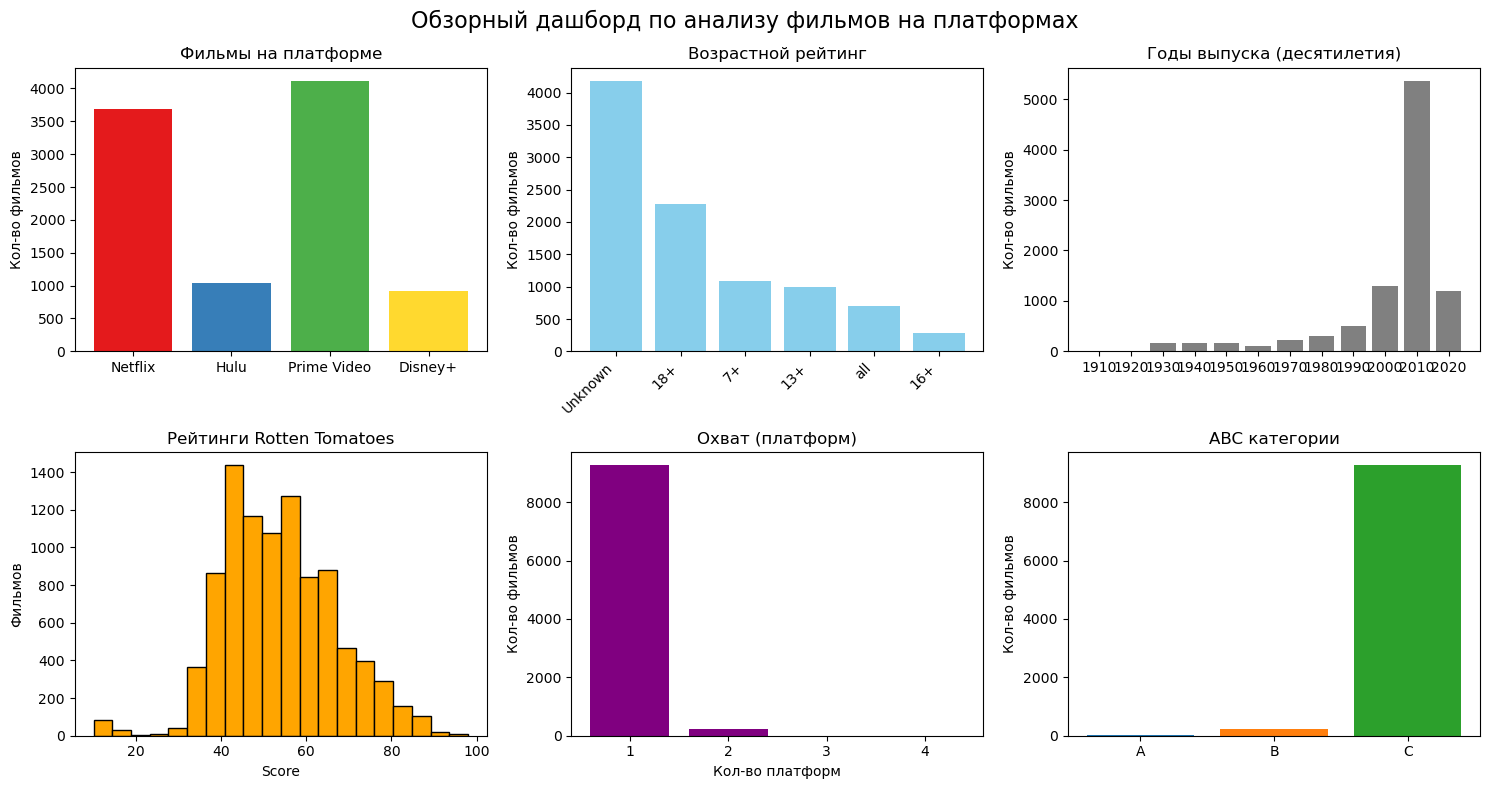

In [25]:
# Построение общего дашборда с 6 графиками (2x3)
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Обзорный дашборд по анализу фильмов на платформах", fontsize=16)

# 1. Фильмы на платформу
axs[0,0].bar(platform_counts.keys(), platform_counts.values(), color=['#e41a1c','#377eb8','#4daf4a','#ffd92f'])
axs[0,0].set_title("Фильмы на платформе")
axs[0,0].set_ylabel("Кол-во фильмов")

# 2. Возрастные рейтинги
axs[0,1].bar(age_counts.index, age_counts.values, color='skyblue')
axs[0,1].set_title("Возрастной рейтинг")
axs[0,1].set_ylabel("Кол-во фильмов")
axs[0,1].set_xticklabels(age_counts.index, rotation=45, ha='right')

# 3. Годы (десятилетия)
axs[0,2].bar(decade_counts.index.astype(str), decade_counts.values, color='gray')
axs[0,2].set_title("Годы выпуска (десятилетия)")
axs[0,2].set_ylabel("Кол-во фильмов")

# 4. Рейтинги Rotten Tomatoes
axs[1,0].hist(ratings, bins=20, color='orange', edgecolor='black')
axs[1,0].set_title("Рейтинги Rotten Tomatoes")
axs[1,0].set_xlabel("Score")
axs[1,0].set_ylabel("Фильмов")

# 5. Охват (число платформ)
axs[1,1].bar(platform_count_dist.index.astype(str), platform_count_dist.values, color='purple')
axs[1,1].set_title("Охват (платформ)")
axs[1,1].set_xlabel("Кол-во платформ")
axs[1,1].set_ylabel("Кол-во фильмов")

# 6. ABC-анализ категорий
axs[1,2].bar(['A','B','C'], [A_films, B_films, C_films], color=['#1f77b4','#ff7f0e','#2ca02c'])
axs[1,2].set_title("ABC категории")
axs[1,2].set_ylabel("Кол-во фильмов")

plt.tight_layout()
plt.show()
